# 🧬 Single-Cell Analysis of Fly Ovary Cells

**Project Goal:**  
Analyze a heterogeneous mix of fly cells from different tissues to identify **cell types**, **marker genes**, and **likely tissue origins**.

---

## Dataset
- File: `data/ovary.tsv`  
- Type: single-cell RNA-seq counts  
- Format: rows = genes, columns = cells (check orientation)  

---

## Tools
- **Python**  
- **Scanpy** (for preprocessing, clustering, visualization)  
- **Pandas** (for data handling)  
- **Matplotlib / Seaborn** (for plots)  
- **FlyBase or literature** (to identify cell-types from marker genes)  

---

## Analysis Plan

1. **Data Loading & QC**
   - Load TSV into a Scanpy `AnnData` object.
   - Inspect cell and gene counts.
   - Filter low-quality cells and genes.

2. **Normalization & Preprocessing**
   - Normalize counts per cell.
   - Log-transform the data.
   - Identify highly variable genes.
   - Scale and run PCA.

3. **Dimensionality Reduction**
   - Compute neighborhood graph.
   - Run **UMAP** and/or **t-SNE** for visualization.

4. **Clustering**
   - Perform clustering (e.g., Leiden algorithm).
   - Visualize clusters on UMAP/t-SNE.

5. **Marker Gene Identification**
   - Perform **differential expression analysis** for each cluster.
   - Identify **marker genes** that define cell-types.

6. **Cell-Type Annotation**
   - Use marker genes and resources like **FlyBase** to infer likely cell-types.
   - Summarize which tissues are present and how many cell-types were found.

---

## Expected Results
- Number of clusters / cell-types.  
- Marker genes per cell-type.  
- Tentative annotation of cell-types with tissue origin.  

---

## Notes
- Ensure **gene names are unique** to avoid errors.  
- Save processed data to `write/ovary.h5ad` for future analysis.

## PARTIE 1: Settings ##

In [11]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import numpy as np
import scipy.sparse as sp

**Trouver path:**

In [ ]:
import os
 
print("Current directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

print("\nSearching for ovary.tsv ...")
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".tsv"):
            print(os.path.join(root, file))

Current directory:
c:\Users\clodr\OneDrive\Documents\EPFL\MASTER\MA2\SINGLE_CELL_BIO\Projet

Files here:
['01.introduction_to_jupyter.html', '02.a.extended_introduction_to_python.html', '02.b.quick_python_overview.html', '03.useful_python_packages_and_examples.html', 'ovary.tsv', 'Project_code.ipynb', 'Single_Cell_Biology_Project']

Searching for ovary.tsv ...
.\ovary.tsv


### a) Load the data

In [5]:
# Load TSV into pandas
df = pd.read_csv("ovary.tsv", sep="\t")  # adjust path if needed

# Convert all data to numeric (coerce non-numeric to NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Optionally fill NaNs with 0 (common for sparse single-cell counts)
df = df.fillna(0)

# Convert to Scanpy AnnData object
adata = sc.AnnData(df.T) #transpose if rows=genes, columns=cells

# Check data
adata.var_names_make_unique #ensure that gene names are unique since may some datasets have repeated symbols

# Optional: filter genes or cells like min.cells/min.features in Seurat
# Remove genes expressed in fewer than 3 cells
sc.pp.filter_genes(adata, min_cells=3)
# Remove cells with fewer than 200 genes detected
sc.pp.filter_cells(adata, min_genes=200)

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


### b) Setting and logging ###

In [6]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.set_figure_params(dpi=80, facecolor="white")
sc.logging.print_header()

results_file = "write/ovary.h5ad"  # the file that will store the analysis results

## PARTIE 2: Pre-processing ##

### a) Quality control: 

C:\Users\clodr\AppData\Local\Temp\ipykernel_15636\3200427738.py:11: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)


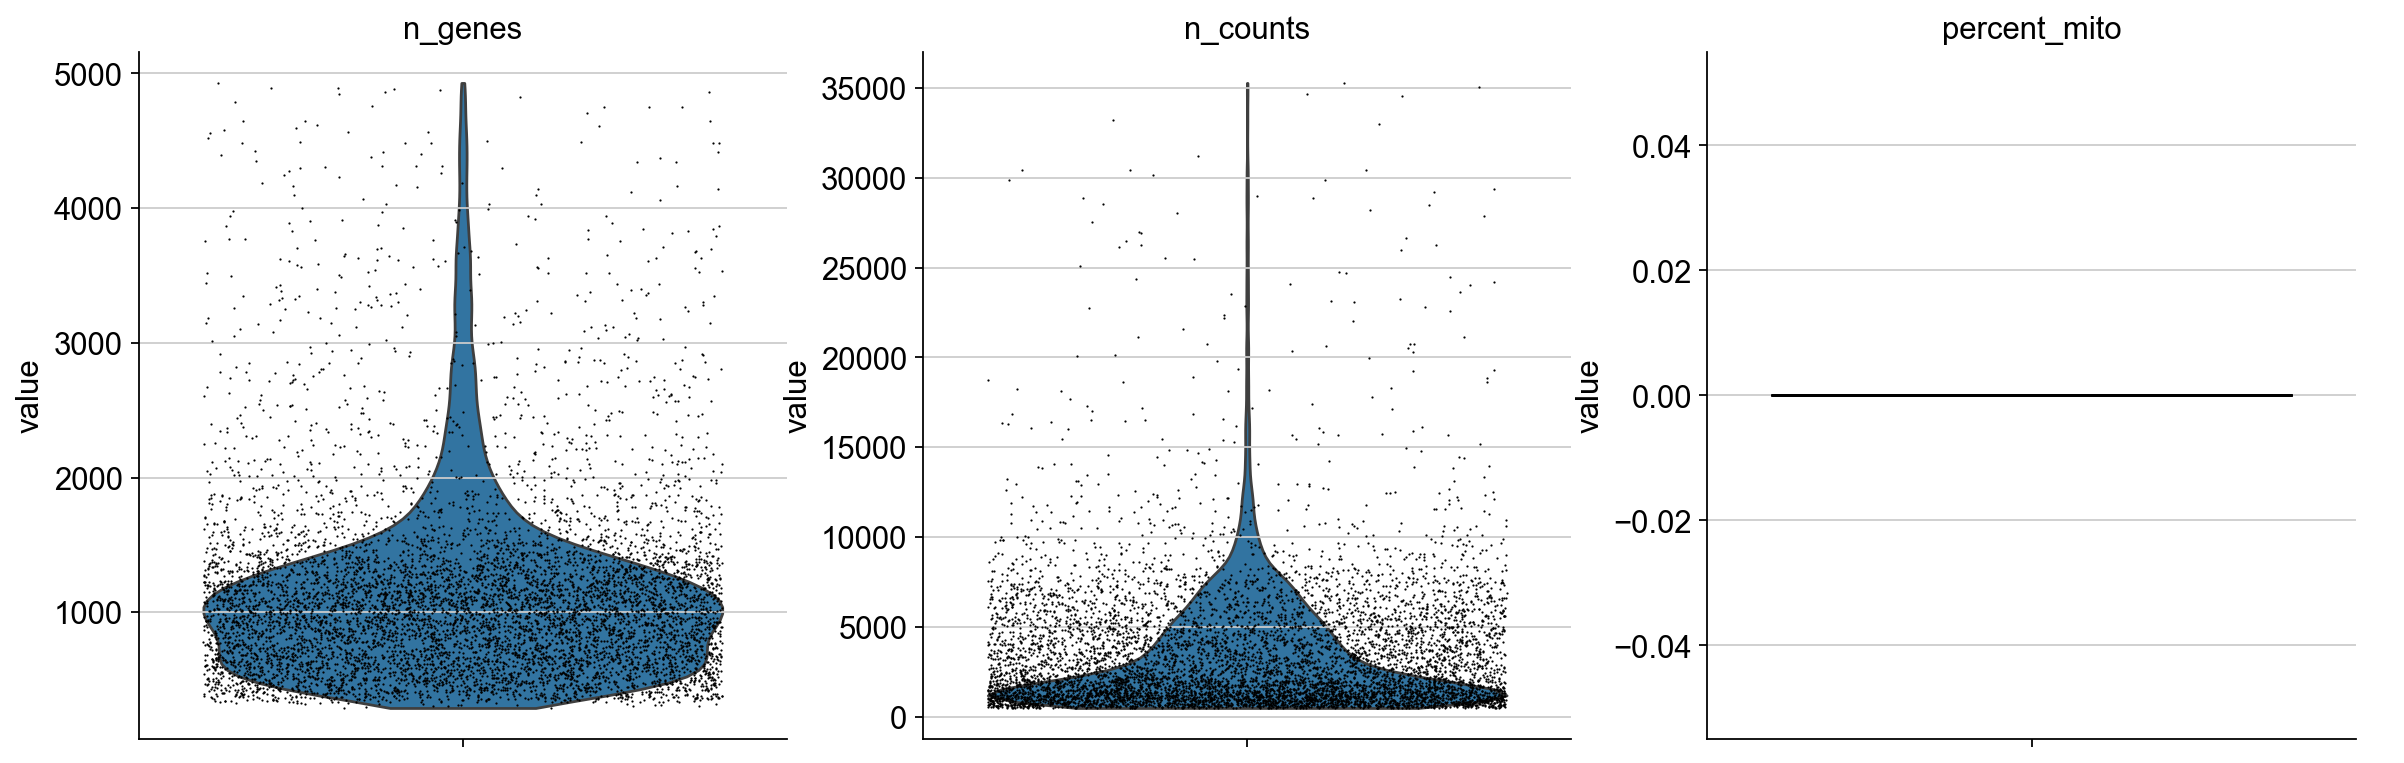

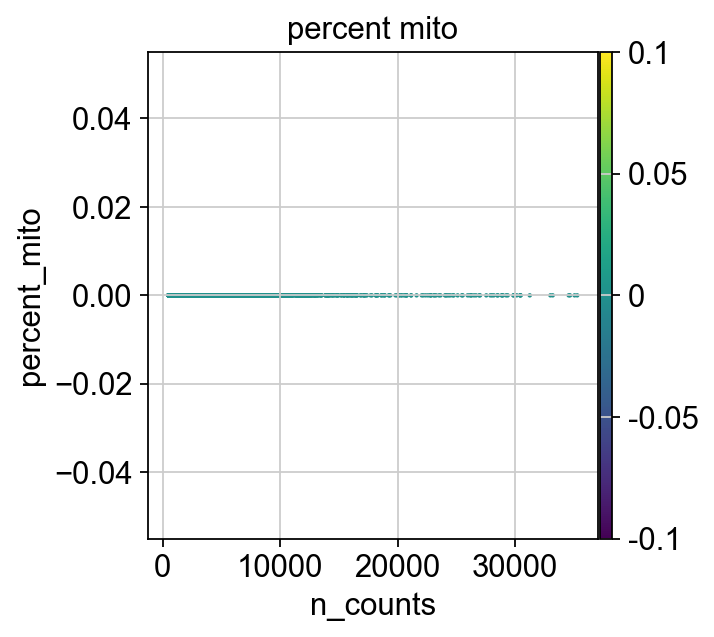

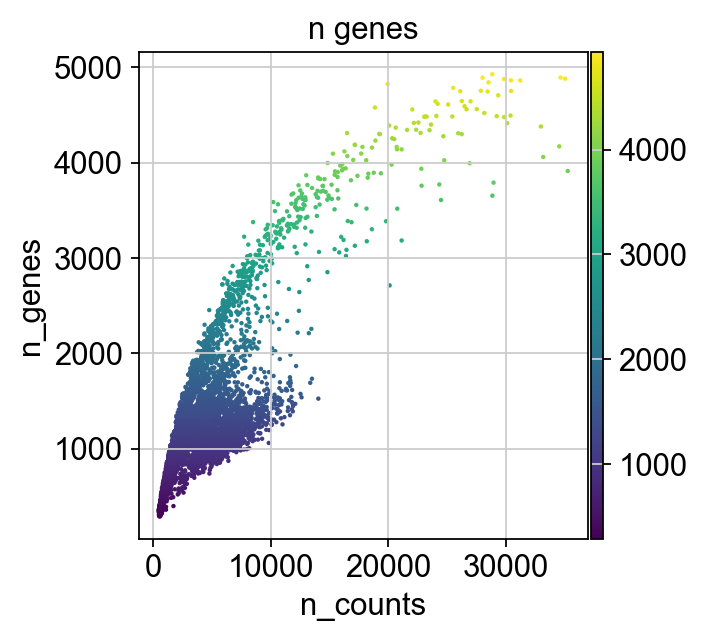

In [9]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import scipy.sparse as sp

# Step 1: Compute QC metrics
if sp.issparse(adata.X):
    adata.obs['n_genes'] = (adata.X > 0).sum(axis=1).A1
    adata.obs['n_counts'] = adata.X.sum(axis=1).A1
else:
    adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)
    adata.obs['n_counts'] = adata.X.sum(axis=1)

# Step 2: Calculate percent mitochondrial genes
mito_genes = [g for g in adata.var_names if g.startswith('mt-') or g.startswith('MT-')]
if sp.issparse(adata.X):
    adata.obs['percent_mito'] = (adata[:, mito_genes].X.sum(axis=1).A1 / adata.obs['n_counts']) * 100
else:
    adata.obs['percent_mito'] = (adata[:, mito_genes].X.sum(axis=1) / adata.obs['n_counts']) * 100

# Step 3: Visualize QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mito'], jitter=0.4, multi_panel=True)

# Scatter plots similar to Seurat's FeatureScatter
sc.pl.scatter(adata, x='n_counts', y='percent_mito', color='percent_mito')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='n_genes')

# Step 4: Filter cells based on thresholds
adata = adata[
    (adata.obs['n_genes'] > 200) &
    (adata.obs['n_genes'] < 5000) &
    (adata.obs['percent_mito'] < 10),
    :
]

After creating the AnnData object (Scanpy equivalent of a Seurat object), the next step is to assess the quality of the cells in the dataset. The goal is to **remove low-quality or abnormal cells** that could bias downstream analysis.  

### Metrics Calculated

1. **Number of genes per cell (`n_genes`)**  
   - Counts how many genes are detected in each cell.  
   - Cells with very few detected genes may be dead or poorly sequenced.  
   - Cells with unusually many genes may represent **doublets** (two cells captured as one).  

2. **Total counts per cell (`n_counts`)**  
   - Total number of transcripts detected in each cell.  
   - Helps identify cells with abnormally high or low sequencing depth.  

3. **Percent mitochondrial transcripts (`percent_mito`)**  
   - Fraction of a cell's transcripts originating from mitochondrial genes.  
   - High mitochondrial content often indicates stressed or dying cells.  
   - For fly ovary data, mitochondrial genes are typically prefixed with `mt-` or `MT-`.  

### Visualization

**Violin plots** are used to examine the distribution of these metrics across all cells. This allows us to **identify outliers** rather than applying arbitrary cutoffs.  

### Filtering
After inspecting the distributions, cells with extreme values are removed:
  - Cells with too few or too many genes.  
  - Cells with excessively high mitochondrial transcript percentages.  
This step ensures that downstream analyses, like clustering and differential expression, focus on **high-quality, biologically meaningful cells**.  

### b) Normalization:


After quality control, the next step is **normalization**.  

In scRNA-seq, the amount of RNA captured per cell can vary greatly. To make gene expression values comparable across cells, we normalize each cell's counts:

1. Scale each cell's total counts to a constant (default: 10,000).  
2. Log-transform the scaled counts to reduce skewness and make the data more suitable for downstream analysis.

This is analogous to TPM (Transcripts Per Million) normalization used in bulk RNA-seq.


In [12]:
# Normalize the data (total-count normalize to 10,000 counts per cell and log-transform)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)  # log(x + 1) transform

C:\Users\clodr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:00)
